In [1]:
# Proposal for GRAIL 2026 -- Fig. 1d
# Figure of spectra for protons

# load plotting parameters
import matplotlib as mpl
import happi
import numpy as np
import matplotlib.pyplot as plt

jetcmap = plt.cm.get_cmap("jet", 9) #generate a jet map with 10 values "rainbow", "jet", YlOrRd
jet_vals = jetcmap(np.arange(9)) #extract those values as an array 
jet_vals[0] = [1.0, 1, 1.0, 1] #change the first value 
jet_vals[8] = [0.0, 0, 0.0, 1] #change the first value 
newcmap = mpl.colors.LinearSegmentedColormap.from_list("mine", jet_vals) 

from matplotlib import font_manager

font_dirs = ['/Users/yao/Documents/Calibri and Cambria Fonts/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Calibri'

plt.rc('text', usetex=False)
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rc('axes', labelsize=18)
plt.rc('legend', fontsize=16)

/var/folders/2t/97rc3fl92tg15k2l_4sk5hsh0000gn/T/ipykernel_94965/3721306218.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jetcmap = plt.cm.get_cmap("jet", 9) #generate a jet map with 10 values "rainbow", "jet", YlOrRd


In [2]:
# load experiment data for proton

import numpy as np
data_energy = np.loadtxt('/Users/yao/Nextcloud/PROJECTS/Apollon/F1-2023/Proton_Spectrum_RCF_MeV_Avg.dat',usecols=0)
data_dnde   = np.loadtxt('/Users/yao/Nextcloud/PROJECTS/Apollon/F1-2023/Proton_Spectrum_RCF_MeV_Avg.dat',usecols=1)
data_error  = np.loadtxt('/Users/yao/Nextcloud/PROJECTS/Apollon/F1-2023/Proton_Spectrum_RCF_MeV_Avg.dat',usecols=2)

In [4]:
# get simulation data for proton

import happi

wkdir = [
        '/Volumes/yaowp2024/ANR_LIOR_2024/LIOR_x4_r*/',
        '/Volumes/yaowp2024/ANR_LIOR_2024/LIOR_x3_r*/'
        ]
S0 = happi.Open(wkdir[0], reference_angular_frequency_SI = 2.*np.pi*3e8/0.8e-6)
S1 = happi.Open(wkdir[1], reference_angular_frequency_SI = 2.*np.pi*3e8/0.8e-6)

simu_energy0 = np.array(S0.Screen(0, units=['mm','fs','MeV','cm^-3']).getAxis('ekin')) # MeV
simu_dnde0   = np.array(S0.Screen(0, units=['mm','fs','MeV','cm^-3']).getData()[-1])   # simulation unit, will be adjusted to experiments

simu_energy1 = np.array(S1.Screen(0, units=['mm','fs','MeV','cm^-3']).getAxis('ekin')) # MeV
simu_dnde1   = np.array(S1.Screen(0, units=['mm','fs','MeV','cm^-3']).getData()[-1])   # simulation unit, will be adjusted to experiments



Loaded simulation '/Volumes/yaowp2024/ANR_LIOR_2024/LIOR_x4_r0/'
Loaded simulation '/Volumes/yaowp2024/ANR_LIOR_2024/LIOR_x4_r1/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics
Loaded simulation '/Volumes/yaowp2024/ANR_LIOR_2024/LIOR_x3_r0/'
Loaded simulation '/Volumes/yaowp2024/ANR_LIOR_2024/LIOR_x3_r1/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics


Saved plot data to /Users/yao/Desktop/data_2PW_exp_sim_8PW_sim.npz


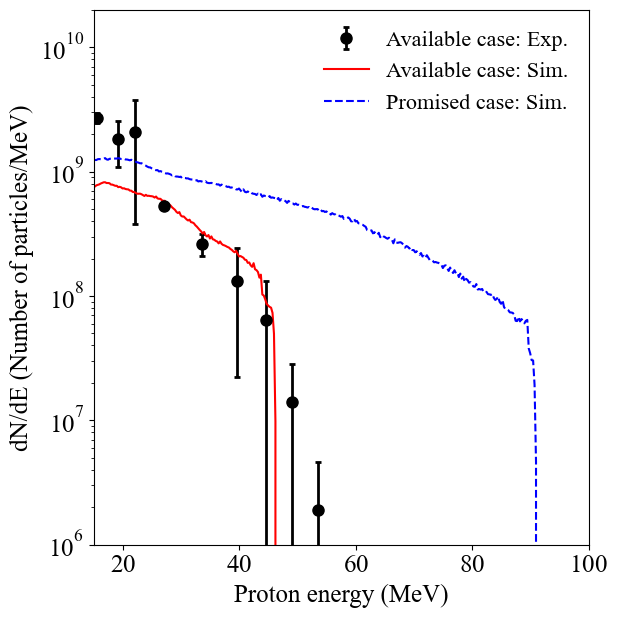

In [7]:
# plot panel (a) with proton energy spectra

width  = 3.14 *2.0
height = width
fig, ax = plt.subplots()

plt.ticklabel_format(axis='both', style='sci',useMathText=True)

fig.subplots_adjust(left=.2, bottom=.2, right=.9, top=.9)
ax.set_yscale('log')

ax.errorbar(data_energy,
             data_dnde,
             yerr=data_error, 
             label='Available case: Exp.',
             fmt='ok',markersize=8,
             ecolor='k',elinewidth=2.0,
            #  mfc='none',
             capsize=2.0, capthick = 2.0,
            )

ax.plot(simu_energy1,
        simu_dnde1*2.3e12, 
        label="Promised case: Sim.",
        color='blue',
        linestyle='--')

ax.plot(simu_energy0,
        simu_dnde0*2.3e12, 
        label="Available case: Sim.",
        color='red')

handles, labels = ax.get_legend_handles_labels()
handles.reverse()
labels.reverse()
ax.legend(handles, labels, 
          fancybox=False, reverse=False, frameon=False
         )

ax.set_xlim([15,100])
ax.set_ylim([1e6, 2e10])
ax.set_xlabel('Proton energy (MeV)')
ax.set_ylabel('dN/dE (Number of particles/MeV)')

fig.set_size_inches(width, height)
fig.tight_layout()

# fig.savefig('/Users/yao/Desktop/spectra_proton.pdf',dpi=600)

# save plotted data for reuse outside the notebook

plot_data_path = '/Users/yao/Desktop/data_2PW_exp_sim_8PW_sim.npz'

np.savez(
    plot_data_path,
    proton_exp_energy=data_energy,
    proton_exp_dnde=data_dnde,
    proton_exp_error=data_error,
    proton_sim_available_energy=simu_energy0,
    proton_sim_available_dnde=simu_dnde0 * 2.3e12,
    proton_sim_promised_energy=simu_energy1,
    proton_sim_promised_dnde=simu_dnde1 * 2.3e12,
)

print(f'Saved plot data to {plot_data_path}')



In [8]:
wkdir = [
        # '/Volumes/yaowp2024/ANR_GRAAL_2025/GRAIL3D_test1', 
        '/Volumes/yaowp2024/ANR_GRAAL_2025/GRAIL3D_test2',
        '/Volumes/yaowp2024/ANR_GRAAL_2025/GRAIL3D_test3_0p5um',  
        '/Volumes/yaowp2024/ANR_GRAAL_2025/GRAIL3D_test4_10PW',
        '/Volumes/yaowp2024/ANR_GRAAL_2025/GRAIL3D_test5_2um_r*',    
        ]

S0 = happi.Open(wkdir[0], reference_angular_frequency_SI = 2.*np.pi*3e8/0.8e-6)
S1 = happi.Open(wkdir[1], reference_angular_frequency_SI = 2.*np.pi*3e8/0.8e-6)
S2 = happi.Open(wkdir[2], reference_angular_frequency_SI = 2.*np.pi*3e8/0.8e-6)
S3 = happi.Open(wkdir[3], reference_angular_frequency_SI = 2.*np.pi*3e8/0.8e-6)

Loaded simulation '/Volumes/yaowp2024/ANR_GRAAL_2025/GRAIL3D_test2'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics
Loaded simulation '/Volumes/yaowp2024/ANR_GRAAL_2025/GRAIL3D_test3_0p5um'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics
Loaded simulation '/Volumes/yaowp2024/ANR_GRAAL_2025/GRAIL3D_test4_10PW'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnost

In [21]:
# energy distribution for ions

simu_energy_1um = np.array(S0.ParticleBinning(3, units=['mm','fs','MeV','cm^-3']).getAxis('ekin')) # MeV
simu_dnde_1um   = np.array(S0.ParticleBinning(3, units=['mm','fs','MeV','cm^-3']).getData()[-2])   # simulation unit, will be adjusted to experiments

simu_energy_1p2um = np.array(S2.ParticleBinning(3, units=['mm','fs','MeV','cm^-3']).getAxis('ekin')) # MeV
simu_dnde_1p2um   = np.array(S2.ParticleBinning(3, units=['mm','fs','MeV','cm^-3']).getData()[-2])   # simulation unit, will be adjusted to experiments

simu_energy_2um = np.array(S3.ParticleBinning(3, units=['mm','fs','MeV','cm^-3']).getAxis('ekin')) # MeV
simu_dnde_2um   = np.array(S3.ParticleBinning(3, units=['mm','fs','MeV','cm^-3']).getData()[-2])   # simulation unit, will be adjusted to experiments



Saved plot data to /Users/yao/Desktop/data_7PW_sims.npz


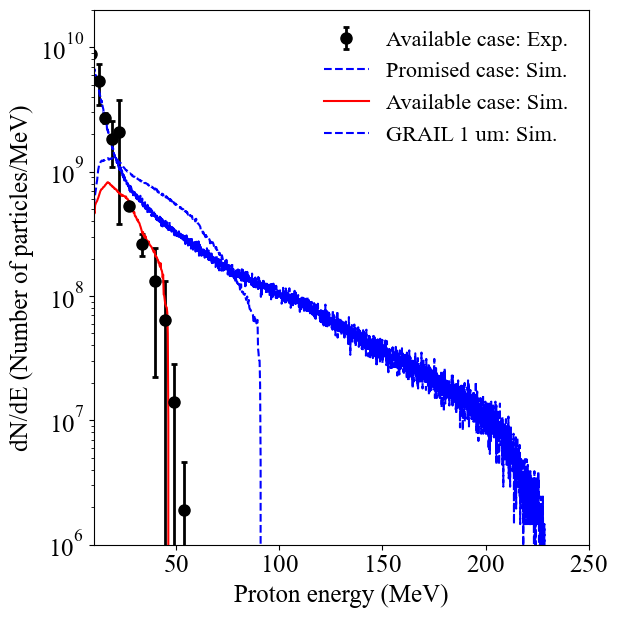

In [22]:
# plot panel (a) with proton energy spectra

width  = 3.14 *2.0
height = width
fig, ax = plt.subplots()

plt.ticklabel_format(axis='both', style='sci',useMathText=True)

fig.subplots_adjust(left=.2, bottom=.2, right=.9, top=.9)
ax.set_yscale('log')

ax.errorbar(data_energy,
             data_dnde,
             yerr=data_error, 
             label='Available case: Exp.',
             fmt='ok',markersize=8,
             ecolor='k',elinewidth=2.0,
            #  mfc='none',
             capsize=2.0, capthick = 2.0,
            )

ax.plot(simu_energy_1um,
         simu_dnde_1um*1e13, 
         label="GRAIL 1 um: Sim.",
         color='blue',
         linestyle='--')

ax.plot(simu_energy0,
        simu_dnde0*2.3e12, 
        label="Available case: Sim.",
        color='red')

ax.plot(simu_energy1,
        simu_dnde1*2.3e12, 
        label="Promised case: Sim.",
        color='blue',
        linestyle='--')

handles, labels = ax.get_legend_handles_labels()
handles.reverse()
labels.reverse()
ax.legend(handles, labels, 
          fancybox=False, reverse=False, frameon=False
         )

ax.set_xlim([10,250])
ax.set_ylim([1e6, 2e10])
ax.set_xlabel('Proton energy (MeV)')
ax.set_ylabel('dN/dE (Number of particles/MeV)')

fig.set_size_inches(width, height)
fig.tight_layout()

# fig.savefig('/Users/yao/Desktop/spectra_proton.pdf',dpi=600)

# save plotted data for reuse outside the notebook

plot_data_path = '/Users/yao/Desktop/data_7PW_sims.npz'

np.savez(
    plot_data_path,
    proton_sim_energy_GRAIL_1um=simu_energy_1um,
    proton_sim_dnde_GRAIL_1um=simu_dnde_1um * 1e13,
    proton_sim_energy_GRAIL_1p2um=simu_energy_1p2um,
    proton_sim_dnde_GRAIL_1p2um=simu_dnde_1p2um * 1e13,
    proton_sim_energy_GRAIL_2um=simu_energy_2um,
    proton_sim_dnde_GRAIL_2um=simu_dnde_2um * 1e13,
)

print(f'Saved plot data to {plot_data_path}')

